### Plotting made easy

In [18]:
network_data = 'nets/MSE/sin_minmax_250_350.pt'
time = 30.2

In [19]:
# Load PLotting Region
import torch
from Modules.Neural_Net import Net

plotting_region = torch.load('Modules/plotting_region.pt', weights_only = True)

# import the net work we want to plot

model = torch.load(network_data, weights_only = False)
if model['scalers'] is not None:
    in_scaler, out_scaler = model['scalers']


# Add time to plotting region
t = time
plotting_region = torch.cat([plotting_region, torch.ones_like(plotting_region[:, 0]).unsqueeze(1)*t], dim=1).to(dtype=torch.float32).numpy()
if model['scalers'] is not None:
    plotting_region = torch.tensor(in_scaler.transform(plotting_region))*(torch.pi/2)
else:
    plotting_region = torch.tensor(plotting_region)    

# set up net work for evaluation

net = Net(torch.sin, *model['model config']).to('cpu')
net.load_state_dict(model['model_state_dict'])
net.eval()

# Get the net work predictions for the plotting region
with torch.no_grad():
    pred = net(plotting_region)

# Reshape for plotting

import numpy as np

z = pred.detach().numpy().reshape(-1, 1)


'__________________'

#Get raw data of the frame
import Modules.preprocess as pp

data  = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(302, 303, 1)
train_beams = list(range(0, 32))

train_data = pp.data_gen(data, beams = train_beams, frames=frames, normalize=None)
train_dataloader  = train_data.get_dataloader(train_data, batch_size=1, num_workers=4)

raw_in, raw_out  =  next(iter(train_dataloader))
raw_z = raw_out.numpy().reshape(-1, 1)
raw_in = raw_in.numpy().reshape(-1, 3)



# Convert raw data and pred data back to original scale
if model['scalers'] is not None:
    pred_z = out_scaler.inverse_transform(z/(np.pi/2))    
else:
    pred_z = z
if model['scalers'] is not None:
    pred_in = in_scaler.inverse_transform(plotting_region.numpy()/(np.pi/2))  # for SIREN scaler
else:
    pred_in = plotting_region.numpy()

raw_x = raw_in[:, 0].reshape(-1, 1)
raw_y = raw_in[:, 1].reshape(-1, 1)

x = pred_in[:, 0].reshape(-1, 1)
y = pred_in[:, 1].reshape(-1, 1)




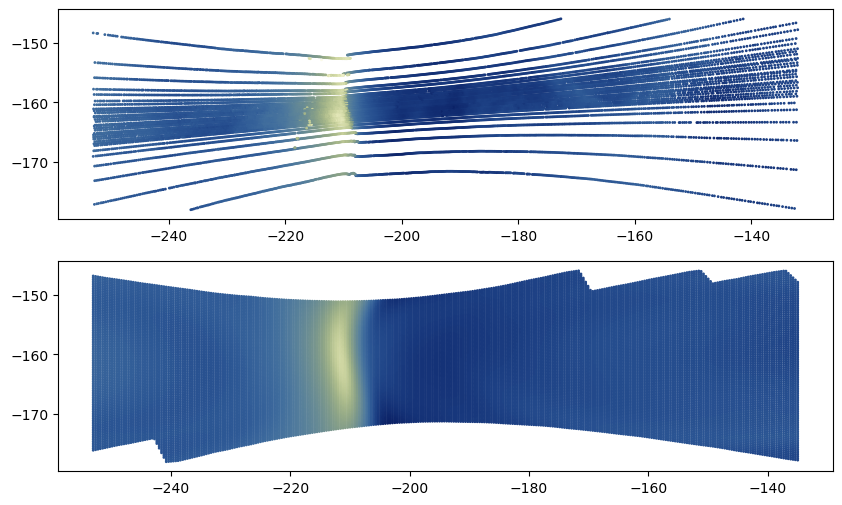

In [20]:
# Make the pretty plot 
import matplotlib.pyplot as plt
import seaborn as sns
import cmcrameri.cm as cmc

#Make the plot
fig, (ax1, ax2) = plt.subplots(2, figsize=(10, 6))

ax1.scatter(raw_x, raw_y, c=raw_z, cmap=cmc.davos, s=1, vmin = 0, vmax = 6)
ax2.scatter(x, y, c=pred_z, cmap=cmc.davos, s=1, vmin = 0, vmax = 6)

plt.show()




# Below here is old plotting attemps.

In [2]:

import torch
from Modules import pre_pro
from Modules.Neural_Net import Net
from Modules.Neural_Net import NetWrapper
from tqdm import tqdm
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc



In [26]:
'net work'

# network_info = torch.load('nets/MSE/mse_0_2000.pt', weights_only=True)
choice = input('MSE or SPT? ')
if choice.lower() == 'mse':
    network_info = torch.load('nets/MSE/MSE_one_frame.pt', weights_only=True)
elif choice.lower() == 'spt':
    network_info = torch.load('nets/SPT/spt_e_100_a_5_f1.pt', weights_only=True)

model_config = network_info['model config']
net = Net(torch.cos, *model_config)
net.load_state_dict(network_info['model_state_dict'])

device = 'cpu'
net = net.to(device)
net.eval()

print('done')

NameError: name 'network_info' is not defined

In [4]:
'data prep'

all_data = torch.load('../../data/data.pt', weights_only= True)
frame = 305
ver_data, train_data, test_data, all_beam_data, cen_beam = pre_pro.setup_data(all_data, frame=frame)
grid_xy, X, Y = pre_pro.create_grid(device)
pd = torch.load('Modules/plotting_region.pt', weights_only=True).to(torch.float32)


ver_xy, ver_z = pre_pro.prepare_tensors(ver_data, device)
train_xy, train_z = pre_pro.prepare_tensors(train_data, device)
test_xy, test_z = pre_pro.prepare_tensors(test_data, device)
all_data_xy, all_data_z = pre_pro.prepare_tensors(all_beam_data, device)
cen_xy, cen_z = pre_pro.prepare_tensors(cen_beam[0], device)

save_path = 'plots/'

new_net = NetWrapper(net, frame = frame)



In [5]:
'Using the plotting region to make plots'

# network = NetWrapper(net, frame = 302)
def plot(newtork):
    try:
        with torch.no_grad():
            pred = network(pd).cpu()
            # print(f"Success! pred shape: {pred.shape}")
    except Exception as e:
        print(f"Error in network call: {e}")

    fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10,5))
    im1 = ax1.scatter(pd[:,0].cpu(), pd[:,1].cpu(), c=pred[:,0], vmin=0, vmax=6, cmap=cmc.davos)
    scat = ax2.scatter(all_data_xy[:,0].detach().cpu(), all_data_xy[:,1].detach().cpu(), c=all_data_z[:,0].detach().cpu(), vmin=0, vmax=6, cmap=cmc.davos, s =5)

    ax1.set_aspect('equal')
    ax2.set_aspect('equal')

    ax1.set_xlim(-250, -135)
    ax1.set_ylim(-178, -146)
    ax2.set_xlim(-250, -135)
    ax2.set_ylim(-178, -146)

    ax1.set_xticklabels([])


    ax2.set_xlabel('Cross Shore (m)', fontweight = 'bold', fontsize = 12)
    ax1.set_ylabel('Along Shore (m)', fontweight = 'bold', fontsize = 10)    
    ax2.set_ylabel('Along Shore (m)', fontweight = 'bold', fontsize = 10)

    cbar = fig.colorbar(im1, ax=[ax1, ax2], location='right', shrink=1.0, aspect=20, fraction = .05)
    cbar.set_label('Sea Surface', fontweight = 'bold',  rotation=270, labelpad=20)

    # save = f"figures/frame_{frame:03d}.png"
    # plt.savefig(save, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

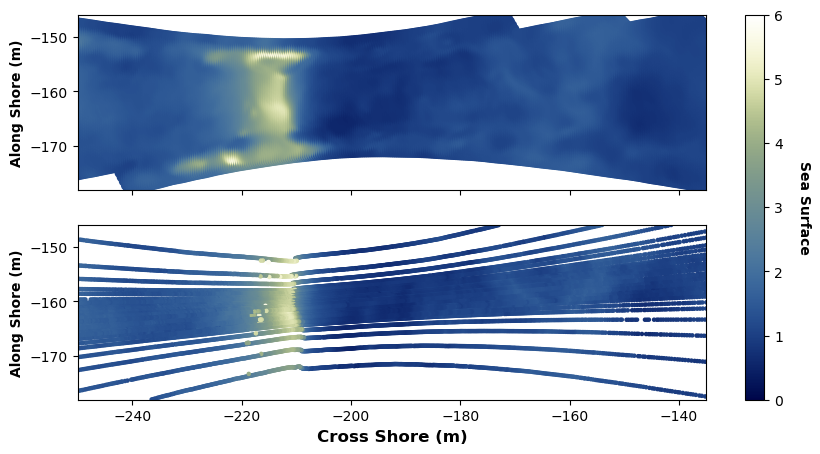

In [6]:
frame = 301

ver_data, train_data, test_data, all_beam_data, cen_beam = pre_pro.setup_data(all_data, frame=frame)
all_data_xy, all_data_z = pre_pro.prepare_tensors(all_beam_data, device)

network = NetWrapper(net, frame = frame)
plot(network)

Processing frames:   0%|          | 0/100 [00:00<?, ?it/s]

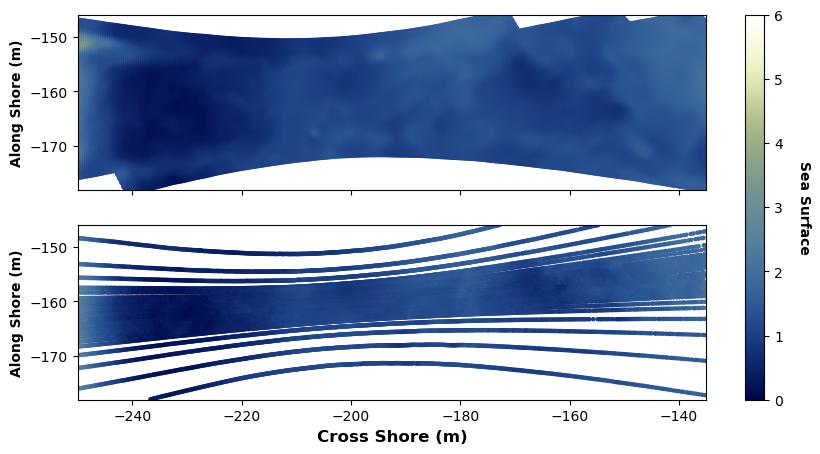

Processing frames:   1%|          | 1/100 [00:03<06:35,  3.99s/it]


KeyboardInterrupt: 

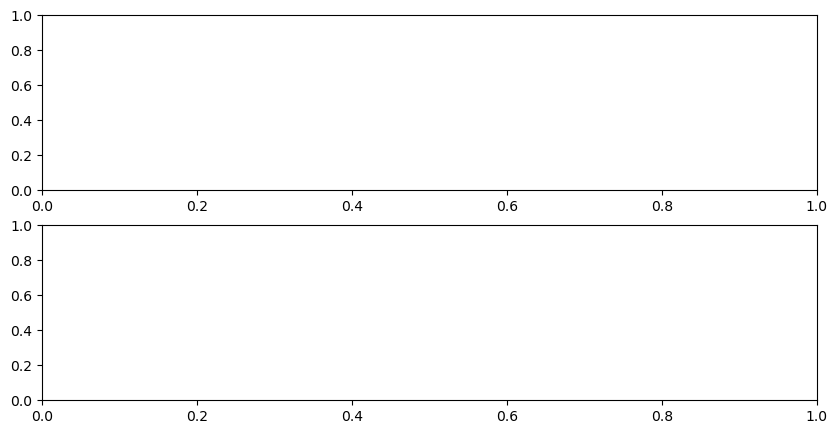

In [7]:

all_data = torch.load('../../data/data.pt', weights_only= True)
for frame in tqdm(range(250,350), desc="Processing frames"):
    
    ver_data, train_data, test_data, all_beam_data, cen_beam = pre_pro.setup_data(all_data, frame=frame)
    all_data_xy, all_data_z = pre_pro.prepare_tensors(all_beam_data, device)

    network = NetWrapper(net, frame = frame)
    plot(network)

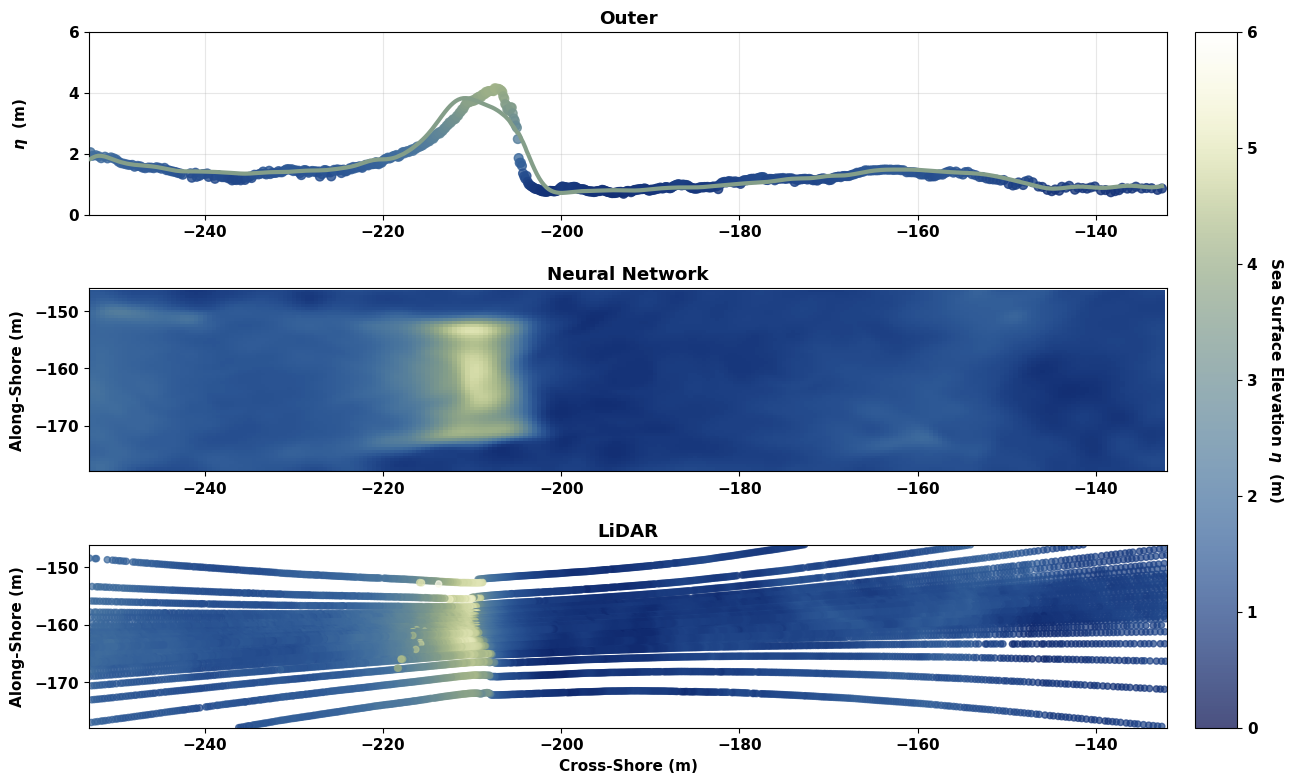

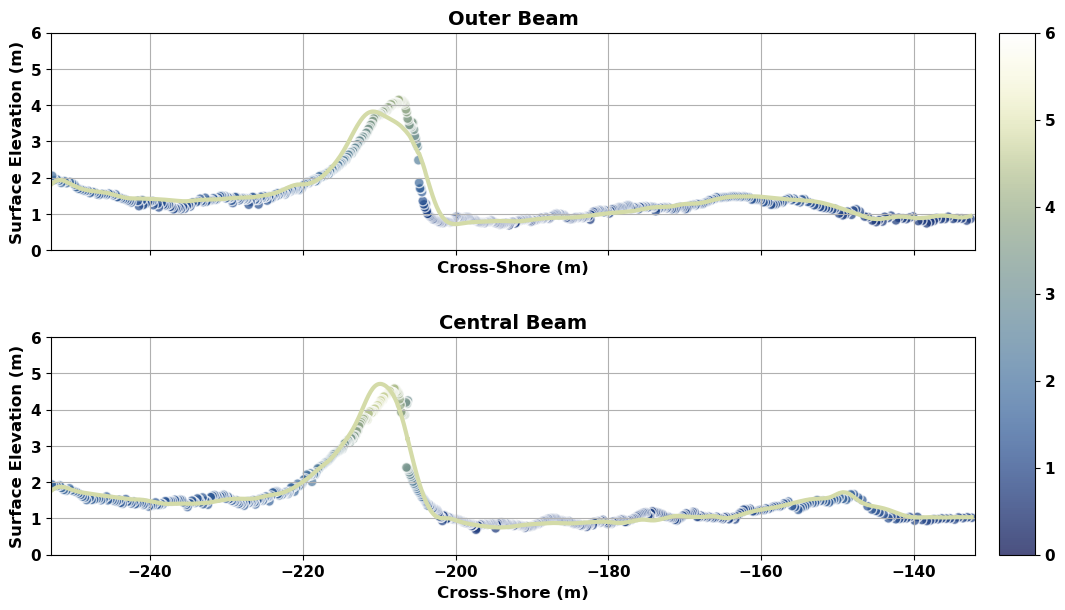

(2.836862564086914, 3.587099552154541, np.float32(1.4013699))

In [7]:
pre_pro.plots(ver_xy, ver_z, grid_xy, X, Y, all_beam_data, new_net, 
                                train_xy, train_z, test_xy, test_z, save_path, cen_xy, cen_z,
                                frame = frame, show = True)

In [ ]:
'Now we just want to plot on frames 0 to 500 and make a hist to see ow good it does'

frame = list(range(500))

trains =[]
tests = []
results = []
save_path = 'plots_new/'

for i in tqdm(frame, desc = 'Frames'):
    ver_data, train_data, test_data, all_beam_data, cen_beam = pre_pro.setup_data(all_data, frame=i)
    ver_xy, ver_z = pre_pro.prepare_tensors(ver_data, device)
    train_xy, train_z = pre_pro.prepare_tensors(train_data, device)
    test_xy, test_z = pre_pro.prepare_tensors(test_data, device)
    all_data_xy, all_data_z = pre_pro.prepare_tensors(all_beam_data, device)
    cen_xy, cen_z = pre_pro.prepare_tensors(cen_beam[0], device)

    new_net = NetWrapper(net, frame = i)

    train, test, mean = pre_pro.plots(ver_xy, ver_z, grid_xy, X, Y, all_beam_data, new_net, 
                                    train_xy, train_z, test_xy, test_z, save_path, cen_xy,
                                    cen_z, frame = i, show = True)
    
    rms = (test + train)/2
    if i % 2 ==0 :
        trains.append(rms)

    if i % 2 == 1:
        tests.append(rms)

    results.append(pre_pro.preformance(grid_xy,all_data_xy, all_data_z, new_net, 
                                train_xy, train_z, test_xy, test_z,bins= 240, save_path=None))
        

torch.save({'train': trains,
            'test': tests}, save_path + 'train_test.pt')

torch.save({'results': results}, save_path + 'results.pt')




In [ ]:
'Avergae gradient in x = [-220, -180] y = [-170, -155] as a function of time'

x = torch.linspace(-220, -180, 40)
y = torch.linspace(-170, -155, 30)
X, Y = torch.meshgrid(x, y, indexing='ij')
grid_xy = torch.stack((X.flatten(), Y.flatten()), dim=-1).to(device)
def add_t(grid_xy, t):
    t = torch.ones(grid_xy.shape[0], 1).to(device) * t
    grid_xyt = torch.cat((grid_xy, t), dim=-1)
    return grid_xyt    

def net_diff(net, grid_xyt):
    pred = net(grid_xyt).sum()
    torch.autograd.backward(pred)
    
    return pred


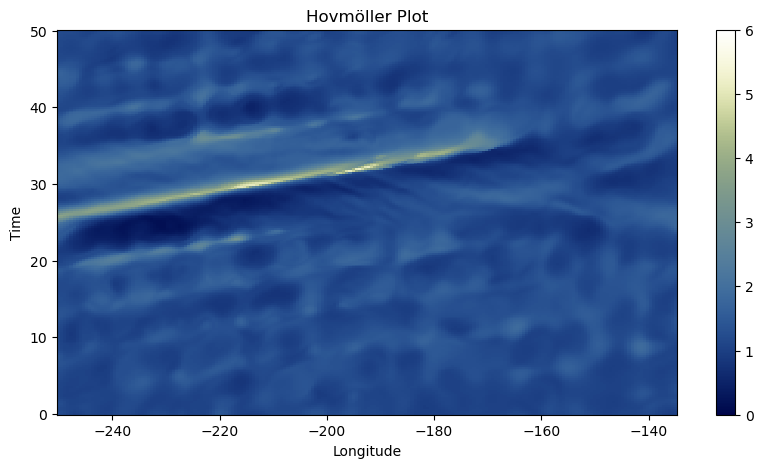

In [8]:
'Hovomollar plot'

x = torch.linspace(-250, -135, 200)
y = -162.5
t = torch.linspace(0, 50, 200)
X, T = torch.meshgrid(x, t, indexing='ij')
grid_xyt = torch.stack((X.flatten(), torch.ones(X.numel()).to(device)*y, T.flatten()), dim=-1).to(device)


with torch.no_grad():
    pred = net(grid_xyt).cpu().numpy()

    Z = pred[:,0].reshape(X.shape)

fig, ax = plt.subplots(figsize=(10,5))
im = ax.pcolormesh(X, T, Z, vmin=0, vmax=6, cmap=cmc.davos, shading='auto')
plt.colorbar(im, ax=ax)
ax.set_xlabel('Longitude')
ax.set_ylabel('Time')
ax.set_title('Hovmöller Plot')
plt.savefig('../latex/overleaf/figures/hovmoller_plot.pdf', dpi=300, bbox_inches='tight')



In [ ]:
import numpy as np
from scipy.interpolate import griddata

delta = .05
resulution = 130
f = 0

pbar = tqdm(total = 500, desc="Creating Hovmoller frames")
while delta < 100:
    pbar.update(1)
    delta += .2
    f+=1
    x = torch.linspace(-250, -135, resulution)
    y = -162.5
    t = torch.linspace(0+delta, 50+delta, resulution)
    X, T = torch.meshgrid(x, t, indexing='ij')
    grid_xyt = torch.stack((X.flatten(), torch.ones(X.numel()).to(device)*y, T.flatten()), dim=-1).to(device)


    with torch.no_grad():
        pred = net(grid_xyt).cpu().numpy()

        Z = pred[:,0].reshape(X.shape)


    x_orig = torch.linspace(-250, -135, resulution)
    t_orig = torch.linspace(0+delta, 50+delta, resulution)
    X_orig, T_orig = torch.meshgrid(x_orig, t_orig, indexing='ij')

    # Higher resolution grid for plotting
    x_smooth = np.linspace(-250, -135, 300)
    t_smooth = np.linspace(0 + delta, 50 + delta, 300)
    X_smooth, T_smooth = np.meshgrid(x_smooth, t_smooth, indexing='ij')

    # Convert PyTorch tensors to NumPy arrays before interpolation
    points = np.column_stack((X_orig.numpy().flatten(), T_orig.numpy().flatten()))
    values = Z.flatten()  # Z should already be numpy from .cpu().numpy()
    Z_smooth = griddata(points, values, (X_smooth, T_smooth), method='cubic')

    fig, ax = plt.subplots(figsize=(10,5))
    im = ax.pcolormesh(X_smooth, T_smooth, Z_smooth, vmin=0, vmax=6, cmap=cmc.davos, shading='gouraud')
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Sea Surface', fontweight = 'bold',  rotation=270, labelpad=20)
    ax.set_xlim( -250, -135)
    ax.set_ylim( 0+delta, 50+delta)    
    ax.set_xlabel('Cross Shore (m)', fontweight = 'bold', fontsize = 12)
    ax.set_ylabel('Time (seconds)', fontweight = 'bold', fontsize = 12)

    plt.savefig(f'../../S3_talk/hovmoller/hovmoller_{f}.png', dpi=300, bbox_inches='tight')
    plt.close()

Creating Hovmoller frames: 100%|██████████| 500/500 [20:56<00:00,  2.48s/it]

### Training Curves

- Training Loss
- Trainng MSE Loss
- Training Regularized Loss

- Verification Loss